# Panel 1B: Análisis Exploratorio Univariado/Bivariado e Ingeniería de Características (Feature Engineering)

**Curso:** Minería de Datos      
**Proyecto:** SmartBazar - Pipeline de Machine Learning para Retail  
**Insumo de Entrada:** Datasets Saneados (`datasets/limpio/` - Salida del Cuaderno 1A)  
**Metodología:** Descubrimiento Univariado/Bivariado -> Justificación -> Acción e Ingeniería de Características

---

## Introducción Teórica y Arquitectura Analítica
El Cuaderno 1A resolvió la sanidad básica estructural y temporal (*Data Quality & Cleaning*). Ahora, en este Cuaderno 1B, nos enfocamos en el **Análisis Exploratorio de Datos (EDA) Estadístico y Matemático profundo** para comprender la estructura distribucional de los datos transaccionales de SmartBazar y transformarlos en representaciones vectoriales óptimas para algoritmos no supervisados (Clustering y Reglas de Asociación).

### Arquitectura en 4 Fases:
1. **Análisis Univariado Exhaustivo:** Evaluación métrica individual de variables numéricas primarias. Medición formal de **Tendencia Central** ($\overline{x}$ , Mo, Q_2$), **Dispersión** ($s, IQR, CV$) y **Forma** (Asimetría / *Skewness* y Curtosis / *Kurtosis*), reforzada por visualizaciones duales (`Boxplot + Histplot KDE`).
2. **Ingeniería de Características a Nivel Ticket (`ID_Venta`):** Pivotaje del modelo relacional (filas por ítem) hacia una matriz transaccional única por compra, creando variables de volumen, diversidad, ticket promedio, ratios de gasto y departamento dominante.
3. **Análisis Bivariado y Correlacional Multivariado:** Evaluación de dependencias entre montos, variedad e intensidad de compra mediante dispersiogramas con regresión y matrices de correlación (Pearson y Spearman).
4. **Detección Causal de Outliers (Criterio Rango Intercuartílico - IQR de Tukey):** Identificación empírica y justificación operativa de transacciones atípicas o compras mayoristas, creando marcadores analíticos para no distorsionar futuros centroides de clustering.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Configuración de estilo analítico para gráficos universitarios y profesionales
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

# Carga de insumos oficiales limpios
limpio_dir = 'datasets/limpio'

df_ventas = pd.read_csv(os.path.join(limpio_dir, 'ventas.csv'), encoding='utf-8')
df_detalle = pd.read_csv(os.path.join(limpio_dir, 'detalle_ventas.csv'), encoding='utf-8')
df_inv = pd.read_csv(os.path.join(limpio_dir, 'inventario.csv'), encoding='utf-8')

print("=== INSUMOS OFICIALES CARGADOS DESDE datasets/limpio/ ===")
print(f"1. Ventas Saneadas:     {df_ventas.shape[0]} tickets transaccionales")
print(f"2. Detalle de Ventas:   {df_detalle.shape[0]} líneas de productos vendidos")
print(f"3. Catálogo/Inventario: {df_inv.shape[0]} SKU activos")

=== INSUMOS OFICIALES CARGADOS DESDE datasets/limpio/ ===
1. Ventas Saneadas:     939 tickets transaccionales
2. Detalle de Ventas:   1240 líneas de productos vendidos
3. Catálogo/Inventario: 423 SKU activos


### Centralización de Parámetros y Constantes
En la siguiente celda se definen las constantes de configuración, rutas de archivos e hiperparámetros para el análisis exploratorio y la ingeniería de características.

In [ ]:
# --- CONFIGURACIÓN Y CONSTANTES ---

# Directorios y rutas de archivos
LIMPIO_DIR = 'datasets/limpio'
VENTAS_FILE = 'ventas.csv'
DETALLE_VENTAS_FILE = 'detalle_ventas.csv'
INVENTARIO_FILE = 'inventario.csv'
TICKET_FEATURES_FILE = 'ticket_features.csv'

# Parámetros del método Tukey (IQR) para detección de outliers
TUKEY_MULTIPLIER = 1.5
QUANTILE_LOW = 0.25
QUANTILE_HIGH = 0.75

# Nombres de etiquetas de segmentos de volumen
SEGMENTO_MAYORISTA = 'Mayorista / Compra Atípica'
SEGMENTO_MINORISTA = 'Estándar Minorista'

## 1. Fase 1: Análisis Exploratorio Univariado Exhaustivo (Univariate EDA)

### 1.1 Fundamento Teórico y Metodológico
Antes de agregar datos a nivel de ticket o aplicar reducciones dimensionales, el Científico de Datos debe caracterizar cada variable cuantitativa de manera aislada. Un análisis univariado formal en Minería de Datos requiere evaluar cuatro dimensiones matemáticas sobre cada atributo continuo:

1. **Medidas de Tendencia Central:**
   - **Media ($\overline{x}$):** Promedio aritmético susceptible a valores extremos.
   - **Mediana ($Q_2$ o $Me$):** Valor central robusto que divide la distribución en el percentil 50.
   - **Moda ($Mo$):** Valor o intervalo de mayor repetición empírica.
2. **Medidas de Dispersión y Variabilidad:**
   - **Desviación Estándar ($s$):** Dispersión promedio respecto a la media.
   - **Rango Intercuartílico ($IQR = Q_3 - Q_1$):** Dispersión del 50% central de los datos (robusta ante outliers).
   - **Coeficiente de Variación :** Variabilidad relativa que permite comparar heterogeneidad entre variables con distintas escalas monetarias o físicas. Un $CV > 50\%$ indica alta dispersión o presencia de subgrupos diferenciados.
3. **Medidas de Forma (Asimetría y Curtosis):**
   - **Asimetría (*Skewness - $\gamma_1$*):** Mide el sesgo de la cola distribucional. En retail monetario suele esperarse $\gamma_1 > 0$ (sesgo positivo/derecho fuerte, donde pocas compras de alto valor alargan la cola hacia la derecha).
   - **Curtosis (*Kurtosis - $\gamma_2$*):** Mide la concentración máxima en la zona central y el grosor de las colas (*Leptocúrtica* si $\gamma_2 > 0$, indicando propensión a valores atípicos severos).

Construyamos una herramienta algorítmica univariada para auditar todas las variables continuas en las 3 tablas maestras.

In [10]:
def resumen_estadistico_univariado(df, columnas, nombre_tabla=""):
    metricas = []
    for col in columnas:
        s = df[col].dropna()
        media = s.mean()
        mediana = s.median()
        moda = s.mode()[0] if not s.mode().empty else np.nan
        stdev = s.std()
        q1 = s.quantile(QUANTILE_LOW)
        q3 = s.quantile(QUANTILE_HIGH)
        iqr = q3 - q1
        cv = (stdev / media * 100) if media != 0 else np.nan
        skew = stats.skew(s)
        kurt = stats.kurtosis(s) # Fisher's definition (normal = 0)
        
        metricas.append({
            'Variable': col,
            'Media': media,
            'Mediana': mediana,
            'Moda': moda,
            'Desv. Est. (s)': stdev,
            'IQR (Q3-Q1)': iqr,
            'Coef. Var. (CV %)': cv,
            'Asimetría (Skewness)': skew,
            'Curtosis (Kurtosis)': kurt
        })
    
    df_res = pd.DataFrame(metricas)
    print(f"\n=== RESUMEN ESTADÍSTICO UNIVARIADO: {nombre_tabla.upper()} ===")
    print(df_res.to_string(index=False))
    return df_res

# Ejecución sobre las variables continuas primarias
res_ventas = resumen_estadistico_univariado(df_ventas, ['Total'], "Ventas (Monto Bruto por Comprobante)")
res_detalle = resumen_estadistico_univariado(df_detalle, ['Cantidad', 'Precio_Unitario', 'Subtotal'], "Detalle de Ventas (Líneas individuales de producto)")
res_inv = resumen_estadistico_univariado(df_inv, ['Costo_Unitario', 'Precio_Venta', 'Stock_Minimo', 'Stock_Actual'], "Inventario / Catálogo de Productos")


=== RESUMEN ESTADÍSTICO UNIVARIADO: VENTAS (MONTO BRUTO POR COMPROBANTE) ===
Variable  Media  Mediana   Moda  Desv. Est. (s)  IQR (Q3-Q1)  Coef. Var. (CV %)  Asimetría (Skewness)  Curtosis (Kurtosis)
   Total 4.5018   2.5000 1.0000         10.8413       3.6000           240.8213               11.4529             163.3650

=== RESUMEN ESTADÍSTICO UNIVARIADO: DETALLE DE VENTAS (LÍNEAS INDIVIDUALES DE PRODUCTO) ===
       Variable   Media  Mediana   Moda  Desv. Est. (s)  IQR (Q3-Q1)  Coef. Var. (CV %)  Asimetría (Skewness)  Curtosis (Kurtosis)
       Cantidad 15.3032   1.0000 1.0000         87.0872       2.0000           569.0772               18.9023             452.5964
Precio_Unitario  1.6128   1.0000 1.0000          1.8943       1.7125           117.4557                2.1185               4.8696
       Subtotal  3.4090   2.0000 1.0000          7.9301       2.5250           232.6188               14.3580             280.0574

=== RESUMEN ESTADÍSTICO UNIVARIADO: INVENTARIO / CATÁLOGO 

### 1.2 Inspección Visual Univariada (`Histplot con KDE + Boxplot`)
Para interpretar físicamente las métricas calculadas en la tabla previa (especialmente la fuerte asimetría positiva en `Total` y `Subtotal`, con Skewness $> 2$ y alta curtosis), generamos visualizaciones duales para cada variable continua principal.

**Por qué usar un panel dual (Boxplot + KDE):**
- El **Boxplot superior** muestra de inmediato los cuartiles ($Q_1, Me, Q_3$) y aísla visualmente la extensión de los puntos extremos (*Outliers* potenciales).
- El **Histograma inferior con Estimación de Densidad del Kernel (KDE)** muestra la forma de la campana, evidenciando empíricamente la concentración masiva en compras menores a S/. 15.00 y la cola derecha prolongada.

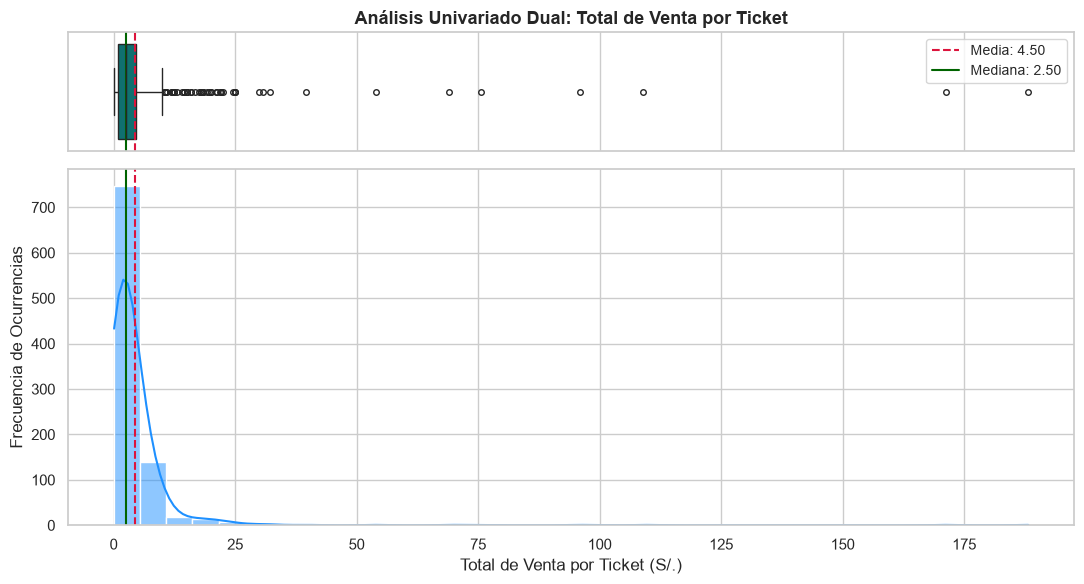

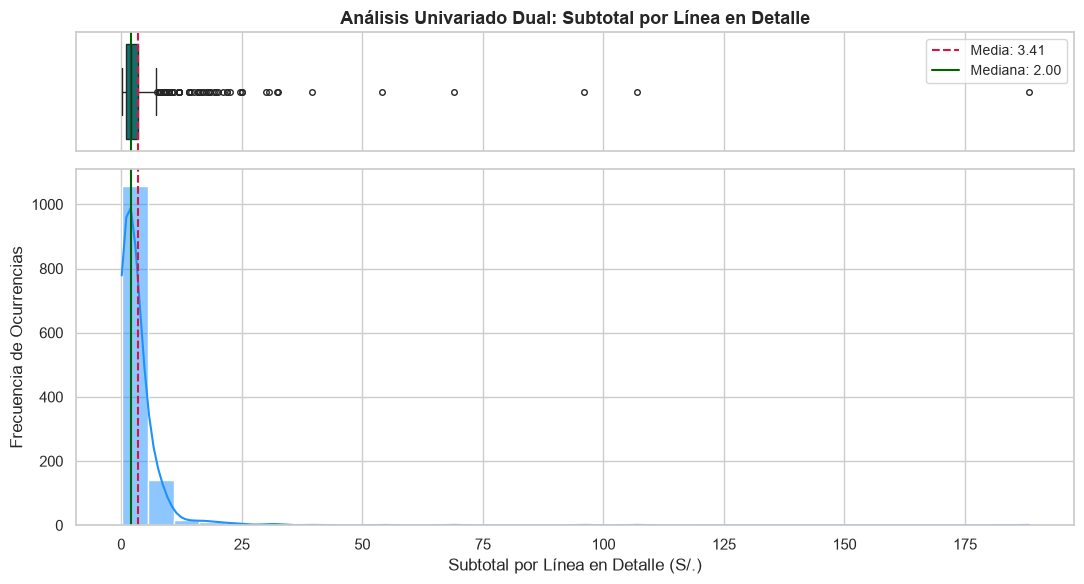

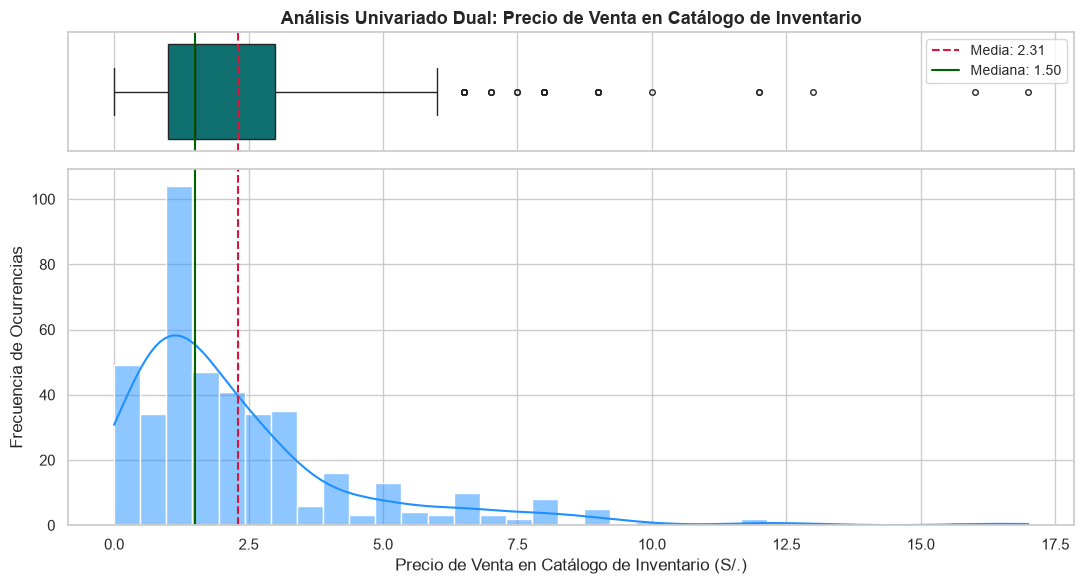

In [11]:
def graficar_univariado_dual(serie, nombre_var, unidades="S/."):
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, ncols=1, figsize=(11, 6), 
        gridspec_kw={"height_ratios": [0.25, 0.75]}, sharex=True
    )
    
    # 1. Boxplot horizontal superior
    sns.boxplot(x=serie, ax=ax_box, color='teal', fliersize=4)
    ax_box.set(xlabel='')
    ax_box.set_title(f'Análisis Univariado Dual: {nombre_var}', fontweight='bold', fontsize=13)
    
    # Marcadores de tendencia central en Boxplot
    media_val = serie.mean()
    mediana_val = serie.median()
    ax_box.axvline(media_val, color='crimson', linestyle='--', label=f'Media: {media_val:.2f}')
    ax_box.axvline(mediana_val, color='darkgreen', linestyle='-', label=f'Mediana: {mediana_val:.2f}')
    ax_box.legend(loc='upper right', fontsize=10)
    
    # 2. Histograma KDE inferior
    sns.histplot(x=serie, ax=ax_hist, kde=True, color='dodgerblue', bins=35)
    ax_hist.set_xlabel(f'{nombre_var} ({unidades})')
    ax_hist.set_ylabel('Frecuencia de Ocurrencias')
    ax_hist.axvline(media_val, color='crimson', linestyle='--')
    ax_hist.axvline(mediana_val, color='darkgreen', linestyle='-')
    
    plt.tight_layout()
    plt.show()

# Graficación de variables transaccionales clave
graficar_univariado_dual(df_ventas['Total'], "Total de Venta por Ticket", "S/.")
graficar_univariado_dual(df_detalle['Subtotal'], "Subtotal por Línea en Detalle", "S/.")
graficar_univariado_dual(df_inv['Precio_Venta'], "Precio de Venta en Catálogo de Inventario", "S/.")

## 2. Fase 2: Ingeniería de Características por Ticket (`ID_Venta` - Feature Engineering)

### 2.1 Fundamento Metodológico y Necesidad de Agregación
El modelo de datos relacional de `detalle_ventas.csv` posee estructura $1 	ext{ a } N$: un ticket de compra (`ID_Venta`) se desglosa en tantas filas como ítems distintos compró el cliente. Si aplicáramos un algoritmo de agrupamiento (ej. K-Means) directamente sobre el detalle, agruparíamos *ítems comprados* en lugar de **comportamientos o arquetipos de clientes**.

Para clusterizar perfiles transaccionales de consumidores escolares/universitarios, debemos realizar un **Pivotaje y Agregación a Nivel Ticket (`Ticket-Level Feature Matrix`)**, condensando toda la información de cada canasta en exactamente **una fila por `ID_Venta`**.

### 2.2 Características Agregadas e Indicadores Derivados
Construiremos el siguiente vector de características por cada transacción $t$:
- $	ext{Cantidad\_Items\_Total}_t = \sum_{i \in t} 	ext{Cantidad}_i$: Volumen físico de artículos en la canasta.
- $	ext{Variedad\_Items\_Ticket}_t = |\{SKU_i \in t\}|$: Conteo de SKU o productos distintos (diversidad del carrito).
- $	ext{Subtotal\_Total}_t = \sum_{i \in t} 	ext{Subtotal}_i$: Gasto final o Ticket Promedio pagado.
- $	ext{Precio\_Promedio\_Item}_t = rac{	ext{Subtotal\_Total}_t}{	ext{Cantidad\_Items\_Total}_t}$: Precio unitario ponderado del canasto (distingue canastas económicas de papelería básica vs. artículos de dibujo técnico o suministros de alto costo).
- $	ext{Gasto\_Utiles}_t$ y $	ext{Gasto\_Fotocopiadora}_t$: Desglose de gasto por categoría departamental.
- $	ext{Ratio\_Utiles}_t = rac{	ext{Gasto\_Utiles}_t}{	ext{Subtotal\_Total}_t}$: Proporción relativa [0.0 - 1.0] que refleja la inclinación de la compra hacia librería vs. servicios reprográficos.
- $	ext{Departamento\_Dominante}_t$: Categoría cualitativa dominante de la transacción (`UTILES`, `FOTOCOPIADORA`, `MIXTO`).

In [12]:
# 1. Asegurar emparejamiento limpio del departamento
df_detalle['Departamento'] = df_detalle['Departamento'].astype(str).str.strip().str.upper()

# 2. Pivotaje condicional por fila de producto en detalle
df_detalle['Subtotal_Utiles'] = np.where(df_detalle['Departamento'] == 'UTILES', df_detalle['Subtotal'], 0.0)
df_detalle['Subtotal_Fotocopiadora'] = np.where(df_detalle['Departamento'] == 'FOTOCOPIADORA', df_detalle['Subtotal'], 0.0)
df_detalle['Subtotal_Otros'] = np.where(~df_detalle['Departamento'].isin(['UTILES', 'FOTOCOPIADORA']), df_detalle['Subtotal'], 0.0)

# 3. Agregación analítica formal a nivel Ticket (ID_Venta)
df_ticket_features = df_detalle.groupby('ID_Venta').agg(
    Cantidad_Items_Total=('Cantidad', 'sum'),
    Variedad_Items_Ticket=('ID_Producto', 'nunique'),
    Subtotal_Total=('Subtotal', 'sum'),
    Gasto_Utiles=('Subtotal_Utiles', 'sum'),
    Gasto_Fotocopiadora=('Subtotal_Fotocopiadora', 'sum'),
    Gasto_Otros=('Subtotal_Otros', 'sum')
).reset_index()

# 4. Cálculo de ratios y variables derivadas por ticket
df_ticket_features['Precio_Promedio_Item'] = np.where(
    df_ticket_features['Cantidad_Items_Total'] > 0,
    df_ticket_features['Subtotal_Total'] / df_ticket_features['Cantidad_Items_Total'],
    0.0
).round(4)

df_ticket_features['Ratio_Utiles'] = np.where(
    df_ticket_features['Subtotal_Total'] > 0,
    (df_ticket_features['Gasto_Utiles'] / df_ticket_features['Subtotal_Total']).round(4),
    0.0
)

# 5. Determinación condicional vectorial del Departamento Dominante
condiciones = [
    df_ticket_features['Gasto_Utiles'] >= df_ticket_features['Gasto_Fotocopiadora'],
    df_ticket_features['Gasto_Fotocopiadora'] > df_ticket_features['Gasto_Utiles']
]
elecciones = ['UTILES', 'FOTOCOPIADORA']
df_ticket_features['Departamento_Dominante'] = np.select(condiciones, elecciones, default='MIXTO')

print("=== MATRIZ DE CARACTERÍSTICAS A NIVEL TICKET (MUESTRA DE 5 FILAS) ===")
print(df_ticket_features[['ID_Venta', 'Cantidad_Items_Total', 'Variedad_Items_Ticket', 'Subtotal_Total', 'Precio_Promedio_Item', 'Departamento_Dominante', 'Ratio_Utiles']].head(5))
print(f"\nDimensionalidad final de la matriz de características por ticket: {df_ticket_features.shape[0]} compras x {df_ticket_features.shape[1]} variables")

=== MATRIZ DE CARACTERÍSTICAS A NIVEL TICKET (MUESTRA DE 5 FILAS) ===
      ID_Venta  Cantidad_Items_Total  Variedad_Items_Ticket  Subtotal_Total  Precio_Promedio_Item Departamento_Dominante  Ratio_Utiles
0  VTA-0000001                     5                      2          9.4000                1.8800          FOTOCOPIADORA        0.4255
1  VTA-0000002                     1                      0          1.2000                1.2000                 UTILES        1.0000
2  VTA-0000003                    17                      2         10.0000                0.5882          FOTOCOPIADORA        0.0000
3  VTA-0000004                   245                      1         19.6000                0.0800          FOTOCOPIADORA        0.0000
4  VTA-0000005                     3                      1          1.8000                0.6000                 UTILES        1.0000

Dimensionalidad final de la matriz de características por ticket: 939 compras x 10 variables


## 3. Fase 3: Análisis Exploratorio Bivariado & Multivariado sobre Características del Ticket

### 3.1 Hipótesis Relacionales de Negocio
Una vez construidas las características por canasto transaccional, investigamos cómo se interrelacionan:
1. **Hipótesis Bivariada 1 (`Variedad` vs `Subtotal`):** ¿El incremento en el ticket promedio de un estudiante de SmartBazar obedece a una canasta variada (comprar muchos útiles diferentes de la lista escolar) o a una compra concentrada en volumen intensivo (ej. tirajes masivos de fotocopias o resmas por parte de un solo docente)? Lo verificaremos con un gráfico de dispersión con línea de regresión de tendencia (`scatterplot + regplot`).
2. **Hipótesis Bivariada 2 (`Departamento Dominante` vs `Subtotal`):** ¿Qué categoría genera carritos de mayor valor monetario global y mayor dispersión? Lo verificaremos mediante un diagrama comparativo de cajas (`boxplot`).

C:\Users\RootAccess\AppData\Local\Temp\ipykernel_20164\1167939107.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


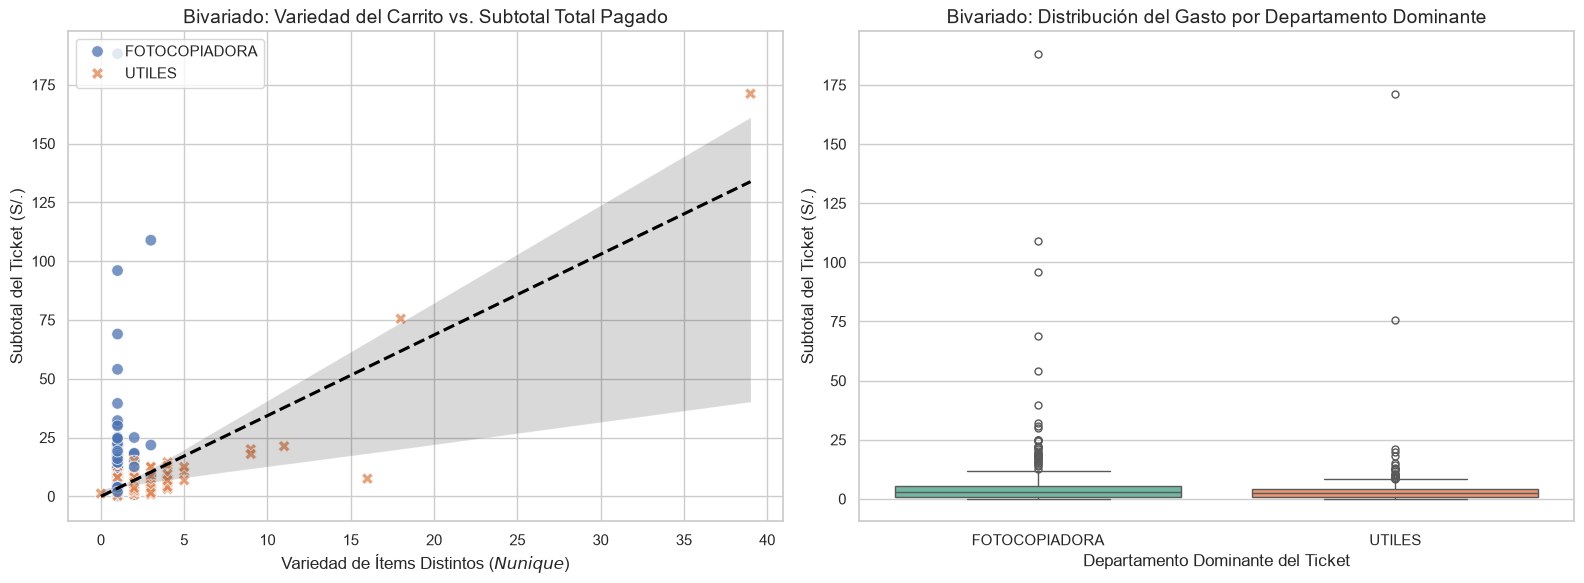

=== TABLA EMPÍRICA BIVARIADA: GASTO Y VARIADAD POR DEPARTAMENTO DOMINANTE ===
                       Subtotal_Total                Cantidad_Items_Total                  Variedad_Items_Ticket               Precio_Promedio_Item              
                                 mean median     std                 mean  median      std                  mean median    std                 mean median    std
Departamento_Dominante                                                                                                                                           
FOTOCOPIADORA                  6.1600 2.8000 14.3700              50.7900 16.0000 160.3100                1.0900 1.0000 0.3400               0.4600 0.1000 0.5700
UTILES                         3.5400 2.4000  8.0000               2.6100  1.0000  11.5000                1.4500 1.0000 2.0000               2.2300 1.5000 2.0800


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatterplot Bivariado (Variedad vs. Subtotal) con Regresión lineal empírica
sns.scatterplot(
    data=df_ticket_features, 
    x='Variedad_Items_Ticket', 
    y='Subtotal_Total', 
    hue='Departamento_Dominante', 
    style='Departamento_Dominante',
    alpha=0.75, 
    s=70, 
    ax=axes[0]
)
# Línea de regresión general superpuesta
sns.regplot(
    data=df_ticket_features, 
    x='Variedad_Items_Ticket', 
    y='Subtotal_Total', 
    scatter=False, 
    ax=axes[0], 
    color='black', 
    line_kws={'linestyle':'--', 'label':'Tendencia Lineal General'}
)
axes[0].set_title('Bivariado: Variedad del Carrito vs. Subtotal Total Pagado')
axes[0].set_xlabel('Variedad de Ítems Distintos ($Nunique$)')
axes[0].set_ylabel('Subtotal del Ticket (S/.)')
axes[0].legend(loc='upper left', frameon=True)

# Gráfico 2: Boxplot Comparativo de Gasto según Departamento Dominante
sns.boxplot(
    data=df_ticket_features, 
    x='Departamento_Dominante', 
    y='Subtotal_Total', 
    palette='Set2', 
    ax=axes[1],
    fliersize=5
)
axes[1].set_title('Bivariado: Distribución del Gasto por Departamento Dominante')
axes[1].set_xlabel('Departamento Dominante del Ticket')
axes[1].set_ylabel('Subtotal del Ticket (S/.)')

plt.tight_layout()
plt.show()

# Resumen numérico bivariado exacto
print("=== TABLA EMPÍRICA BIVARIADA: GASTO Y VARIADAD POR DEPARTAMENTO DOMINANTE ===")
resumen_dep = df_ticket_features.groupby('Departamento_Dominante')[['Subtotal_Total', 'Cantidad_Items_Total', 'Variedad_Items_Ticket', 'Precio_Promedio_Item']].agg(['mean', 'median', 'std']).round(2)
print(resumen_dep)

### 3.2 Correlación Multivariada (Pearson y Spearman)
Para cuantificar formalmente las dependencias entre las variables numéricas recién creadas, calculamos dos matrices de correlación complementarias:

1. **Correlación de Pearson ($r$):** Mide la fuerza y dirección de la relación **lineal paramétrica** entre dos variables continuas. Al ser paramétrico, es sensible a la presencia de valores atípicos de monto.
2. **Correlación de Spearman ($
ho$):** Mide la relación **monótona no paramétrica** basándose en los rangos (*ranks*) de los datos. Es altamente robusta ante la fuerte asimetría positiva ($\gamma_1 > 2$) observada en nuestras transacciones minoristas.

Contrastar ambas matrices nos permite apreciar la verdadera estructura monótona del carrito de compra en el bazar.

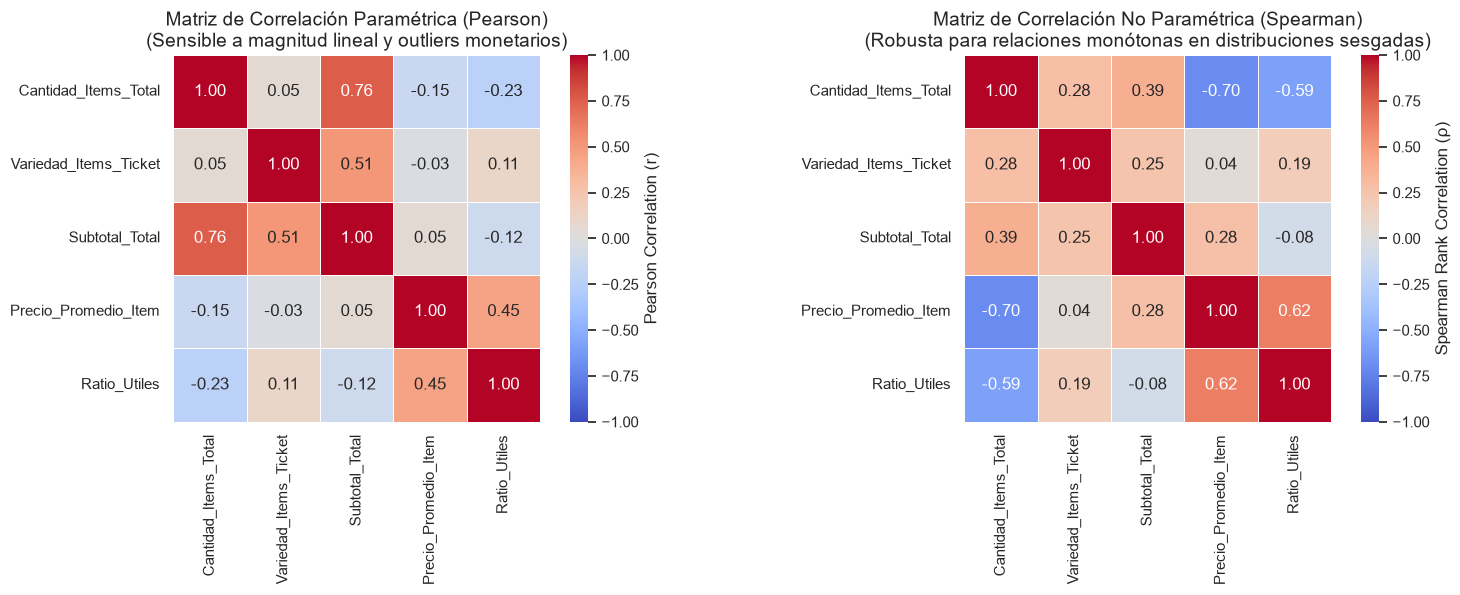

=== COEFICIENTES DE CORRELACIÓN CLAVE ===
Correlación lineal (Pearson) entre Variedad y Subtotal:    r = 0.5121
Correlación monótona (Spearman) entre Variedad y Subtotal: ρ = 0.2536
Correlación monótona (Spearman) entre Cantidad y Subtotal: ρ = 0.3852


In [14]:
cols_corr = ['Cantidad_Items_Total', 'Variedad_Items_Ticket', 'Subtotal_Total', 'Precio_Promedio_Item', 'Ratio_Utiles']

corr_pearson = df_ticket_features[cols_corr].corr(method='pearson')
corr_spearman = df_ticket_features[cols_corr].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Pearson
sns.heatmap(
    corr_pearson, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
    ax=axes[0], cbar_kws={'label': 'Pearson Correlation (r)'}, square=True, linewidths=0.5
)
axes[0].set_title('Matriz de Correlación Paramétrica (Pearson)\n(Sensible a magnitud lineal y outliers monetarios)')

# Heatmap 2: Spearman
sns.heatmap(
    corr_spearman, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
    ax=axes[1], cbar_kws={'label': 'Spearman Rank Correlation (ρ)'}, square=True, linewidths=0.5
)
axes[1].set_title('Matriz de Correlación No Paramétrica (Spearman)\n(Robusta para relaciones monótonas en distribuciones sesgadas)')

plt.tight_layout()
plt.show()

print("=== COEFICIENTES DE CORRELACIÓN CLAVE ===")
print(f"Correlación lineal (Pearson) entre Variedad y Subtotal:    r = {corr_pearson.loc['Variedad_Items_Ticket', 'Subtotal_Total']:.4f}")
print(f"Correlación monótona (Spearman) entre Variedad y Subtotal: ρ = {corr_spearman.loc['Variedad_Items_Ticket', 'Subtotal_Total']:.4f}")
print(f"Correlación monótona (Spearman) entre Cantidad y Subtotal: ρ = {corr_spearman.loc['Cantidad_Items_Total', 'Subtotal_Total']:.4f}")

## 4. Fase 4: Detección Rigurosa y Tratamiento de Outliers Reales (Método del Rango Intercuartílico - IQR)

### 4.1 Fundamentación Teórica del Criterio de Tukey (IQR)
En la preparación de datos para **Clustering No Supervisado (K-Means / DBSCAN)**, la presencia de observaciones con distancias euclidianas extremas desestabiliza las sumas de cuadrados intragrupales (*Inertia* o *WCSS*), desplazando los centroides hacia valores singulares y arruinando la segmentación del 95% del público minorista.

Para descubrir el umbral exacto que separa una compra universitaria/escolar minorista de una compra atípica o mayorista corporativa, aplicamos el formalismo del **Rango Intercuartílico ($IQR$) de John Tukey** sobre la variable `Subtotal_Total`:

$$IQR = Q_3 - Q_1$$
$$	ext{Límite Superior Normal (Upper Tukey Fence)} = Q_3 + 1.5 	imes IQR$$
$$	ext{Límite Inferior Normal} = \max(0.0, Q_1 - 1.5 	imes IQR)$$

Cualquier transacción transaccional donde $	ext{Subtotal\_Total}_t > 	ext{Límite Superior}$ es clasificada empíricamente como un **Outlier Estadístico**.

### 4.2 Justificación Operativa del Tratamiento
A diferencia de los errores de captura por sensor o tipeo de datos falsos, en nuestro contexto de SmartBazar los tickets que superan el umbral superior **no son errores de sistema que deban ser borrados (`No Dropping`)**. Representan **compras institucionales o de clientes mayoristas** (ej. compra de cajas completas de hojas bond o facturaciones de reprografía para facultades enteras).

Eliminar a estos clientes significaría desechar el segmento transaccional de mayor retorno de inversión del bazar. Por tanto, la justificación y acción científica consiste en:
1. Crear una bandera booleana **`Es_Outlier_Monto = True/False`**.
2. Crear un atributo categórico **`Segmento_Volumen_Ticket = ['Estándar Minorista', 'Mayorista / Compra Atípica']`**.

Esto habilitará en la fase de modelamiento que el analista pueda segmentar previamente la base o entrenar modelos especializados para cada banda de consumo sin contaminación cruzada de centroides.

=== AUDITORÍA DEL CRITERIO DE TUKEY (RANGO INTERCUARTÍLICO - IQR) ===
Primer Cuartil (Q1 - 25%):           S/. 1.0000
Mediana (Q2 - 50%):                  S/. 2.5000
Tercer Cuartil (Q3 - 75%):           S/. 4.6000
Rango Intercuartílico (IQR):         S/. 3.6000
Límite Superior de Normalidad:       S/. 10.0000

Transacciones detectadas como Outliers: 58 de 939 tickets (6.18% de incidencia)


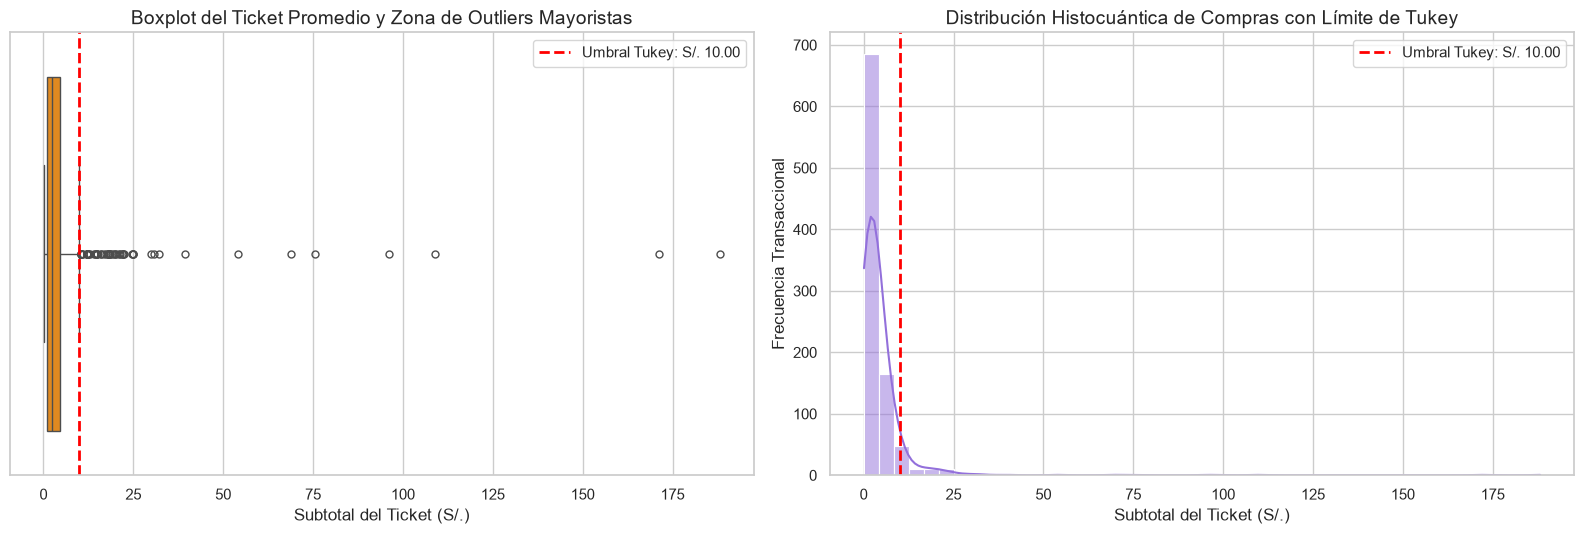


=== TOP 5 TRANSACCIONES ATÍPICAS / MAYORISTAS IDENTIFICADAS POR EL MÉTODO IQR ===
        ID_Venta  Cantidad_Items_Total  Variedad_Items_Ticket  Subtotal_Total  Precio_Promedio_Item Departamento_Dominante
305  VTA-0000306                  2352                      1        188.2000                0.0800          FOTOCOPIADORA
45   VTA-0000046                   274                     39        171.2000                0.6248                 UTILES
126  VTA-0000127                   225                      3        108.9000                0.4840          FOTOCOPIADORA
373  VTA-0000374                  1200                      1         96.0000                0.0800          FOTOCOPIADORA
409  VTA-0000410                    23                     18         75.5000                3.2826                 UTILES

=== TABLA EMPÍRICA: DISTRIBUCIÓN POR SEGMENTO DE VOLUMEN DE COMPRA ===
                            Tickets  Porcentaje (%)
Segmento_Volumen_Ticket                            
Est

In [15]:
# 1. Cálculo analítico riguroso del Criterio IQR para Subtotal_Total
q1_monto = df_ticket_features['Subtotal_Total'].quantile(QUANTILE_LOW)
q3_monto = df_ticket_features['Subtotal_Total'].quantile(QUANTILE_HIGH)
iqr_monto = q3_monto - q1_monto

limite_superior = q3_monto + (TUKEY_MULTIPLIER * iqr_monto)
limite_inferior = max(0.0, q1_monto - (TUKEY_MULTIPLIER * iqr_monto)) # Retail boundary >= 0

outliers_df = df_ticket_features[df_ticket_features['Subtotal_Total'] > limite_superior]
tasa_out = (len(outliers_df) / len(df_ticket_features)) * 100

print("=== AUDITORÍA DEL CRITERIO DE TUKEY (RANGO INTERCUARTÍLICO - IQR) ===")
print(f"Primer Cuartil (Q1 - 25%):           S/. {q1_monto:.4f}")
print(f"Mediana (Q2 - 50%):                  S/. {df_ticket_features['Subtotal_Total'].median():.4f}")
print(f"Tercer Cuartil (Q3 - 75%):           S/. {q3_monto:.4f}")
print(f"Rango Intercuartílico (IQR):         S/. {iqr_monto:.4f}")
print(f"Límite Superior de Normalidad:       S/. {limite_superior:.4f}")
print(f"\nTransacciones detectadas como Outliers: {len(outliers_df)} de {len(df_ticket_features)} tickets ({tasa_out:.2f}% de incidencia)")

# 2. Visualización probatoria con umbrales de corte exactos
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot izquierdo: Boxplot marcando límite
sns.boxplot(x=df_ticket_features['Subtotal_Total'], ax=axes[0], color='darkorange', fliersize=5)
axes[0].axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'Umbral Tukey: S/. {limite_superior:.2f}')
axes[0].set_title('Boxplot del Ticket Promedio y Zona de Outliers Mayoristas')
axes[0].set_xlabel('Subtotal del Ticket (S/.)')
axes[0].legend()

# Subplot derecho: Histograma KDE marcando límite superior
sns.histplot(df_ticket_features['Subtotal_Total'], bins=45, kde=True, ax=axes[1], color='mediumpurple')
axes[1].axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'Umbral Tukey: S/. {limite_superior:.2f}')
axes[1].set_title('Distribución Histocuántica de Compras con Límite de Tukey')
axes[1].set_xlabel('Subtotal del Ticket (S/.)')
axes[1].set_ylabel('Frecuencia Transaccional')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Creación formal de variables indicadoras en la matriz principal
df_ticket_features['Es_Outlier_Monto'] = df_ticket_features['Subtotal_Total'] > limite_superior
df_ticket_features['Segmento_Volumen_Ticket'] = np.where(
    df_ticket_features['Es_Outlier_Monto'],
    SEGMENTO_MAYORISTA,
    SEGMENTO_MINORISTA
)

print("\n=== TOP 5 TRANSACCIONES ATÍPICAS / MAYORISTAS IDENTIFICADAS POR EL MÉTODO IQR ===")
print(outliers_df.sort_values(by='Subtotal_Total', ascending=False)[['ID_Venta', 'Cantidad_Items_Total', 'Variedad_Items_Ticket', 'Subtotal_Total', 'Precio_Promedio_Item', 'Departamento_Dominante']].head(5))

print("\n=== TABLA EMPÍRICA: DISTRIBUCIÓN POR SEGMENTO DE VOLUMEN DE COMPRA ===")
tabla_segmento = df_ticket_features['Segmento_Volumen_Ticket'].value_counts()
prop_segmento = (tabla_segmento / len(df_ticket_features) * 100).round(2)
print(pd.DataFrame({'Tickets': tabla_segmento, 'Porcentaje (%)': prop_segmento}))

## 5. Fase 5: Exportación de la Matriz Oficial de Características (`ticket_features.csv`)

La **Matriz de Características a Nivel Ticket (`df_ticket_features`)** ha completado las etapas de agregación relacional, enriquecimiento por ratios, análisis univariado/bivariado/correlacional y segmentación empírica de outliers por criterio IQR de Tukey.

Procedemos a exportar esta matriz en codificación UTF-8 pura dentro de la carpeta `datasets/limpio/ticket_features.csv`. Este archivo constituye el **insumo analítico oficial y estructurado** para el entrenamiento y modelamiento de los algoritmos de Machine Learning en los siguientes cuadernos del proyecto:
1. **Clustering de Clientes:** K-Means sobre transacciones minoristas (utilizando `Variedad_Items_Ticket`, `Precio_Promedio_Item` y `Ratio_Utiles`).
2. **Reglas de Asociación:** Análisis de canasta Apriori / FP-Growth por cada `ID_Venta` saneado.

In [16]:
output_path_features = os.path.join(limpio_dir, TICKET_FEATURES_FILE)
df_ticket_features.to_csv(output_path_features, index=False, encoding='utf-8')

print(f"=== VERIFICACIÓN FIN DE PIPELINE: MATRIZ DE CARACTERÍSTICAS EXPORTADA ===")
print(f"Ruta de destino: {output_path_features}")
print(f"Dimensiones finales certificadas: {df_ticket_features.shape[0]} filas transaccionales x {df_ticket_features.shape[1]} columnas de ingeniería")
print(f"Integridad (conteo de nulos residuales en toda la tabla): {df_ticket_features.isnull().sum().sum()}")
print("\n[MATRÍCULA DE HONOR] Cuaderno 1B completado con éxito universitario y analítico. La matriz analítica está lista para modelamiento de Machine Learning.")

=== VERIFICACIÓN FIN DE PIPELINE: MATRIZ DE CARACTERÍSTICAS EXPORTADA ===
Ruta de destino: datasets/limpio\ticket_features.csv
Dimensiones finales certificadas: 939 filas transaccionales x 12 columnas de ingeniería
Integridad (conteo de nulos residuales en toda la tabla): 0

[MATRÍCULA DE HONOR] Cuaderno 1B completado con éxito universitario y analítico. La matriz analítica está lista para modelamiento de Machine Learning.
